In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Global_Superstore2.csv", encoding='latin1', engine='python', on_bad_lines='skip')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,31-07-2012,31-07-2012,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7.0,0,762.1845,933.57,Critical
1,26341,IN-2013-77878,05-02-2013,07-02-2013,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9.0,0.1,-288.7650,923.63,Critical
2,25330,IN-2013-71249,17-10-2013,18-10-2013,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9.0,0.1,919.9710,915.49,Medium
3,13524,ES-2013-1579342,28-01-2013,30-01-2013,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5.0,0.1,-96.5400,910.16,Medium
4,47221,SG-2013-4320,05-11-2013,06-11-2013,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8.0,0,311.5200,903.04,Critical


In [4]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
df.describe()

Shape: (84822, 24)

Columns:
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'City', 'State', 'Country',
       'Postal Code', 'Market', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit', 'Shipping Cost', 'Order Priority'],
      dtype='object')

Missing Values:
Row ID                0
Order ID              0
Order Date            0
Ship Date             0
Ship Mode             0
Customer ID           0
Customer Name         0
Segment               0
City                  1
State                 0
Country               1
Postal Code       67756
Market                2
Region                2
Product ID            2
Category              2
Sub-Category          2
Product Name          2
Sales                 2
Quantity              2
Discount              2
Profit                3
Shipping Cost         3
Order Priority        4
dtype: int64

Da

,Row ID,Sales,Quantity,Profit
count,84822.000000,84820.000000,84820.000000,84819.000000
mean,25993.568933,175.415053,3.291220,19.242287
std,14968.198813,394.162574,2.182158,138.471406
min,1.000000,-1.536000,0.000000,-6599.978000
25%,12845.000000,25.344000,2.000000,-0.030000
50%,26324.500000,59.460000,3.000000,7.200000
75%,39099.750000,152.500125,4.000000,25.188800
max,51290.000000,22638.480000,14.000000,8399.976000


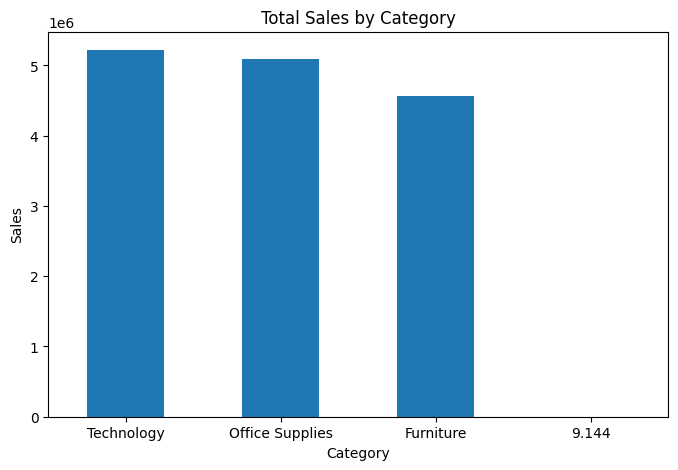

In [5]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
category_sales.plot(kind="bar")

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.show()

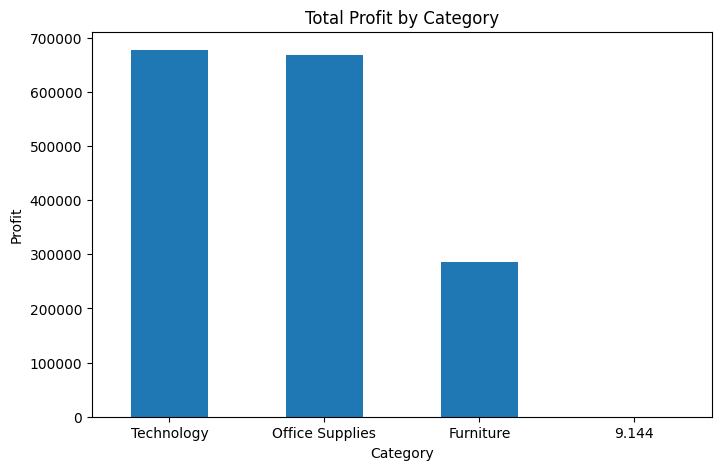

In [6]:
category_profit = df.groupby("Category")["Profit"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
category_profit.plot(kind="bar")

plt.title("Total Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.xticks(rotation=0)
plt.show()

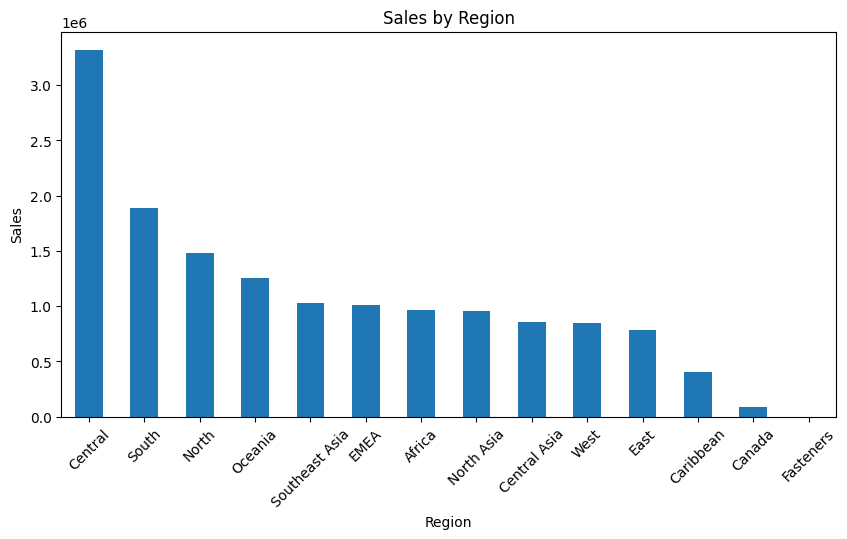

In [7]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
region_sales.plot(kind="bar")

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

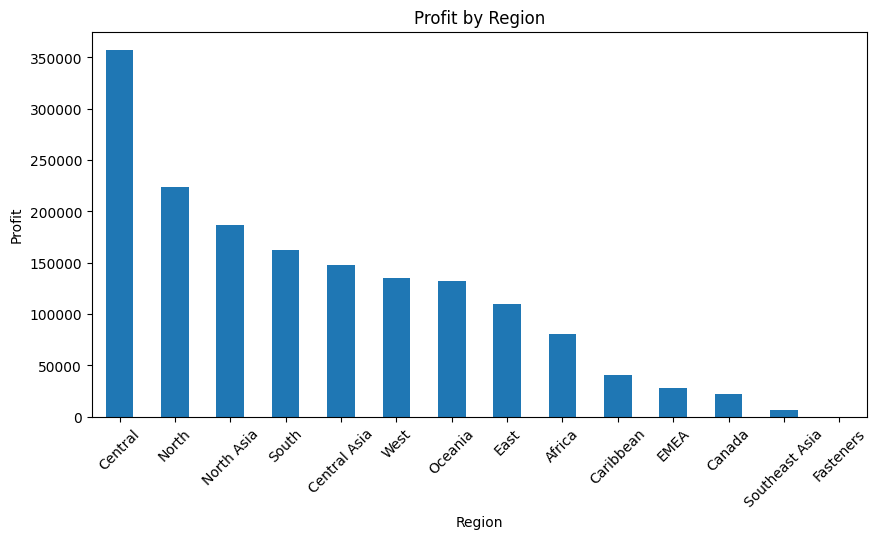

In [8]:
region_profit = df.groupby("Region")["Profit"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
region_profit.plot(kind="bar")

plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.show()

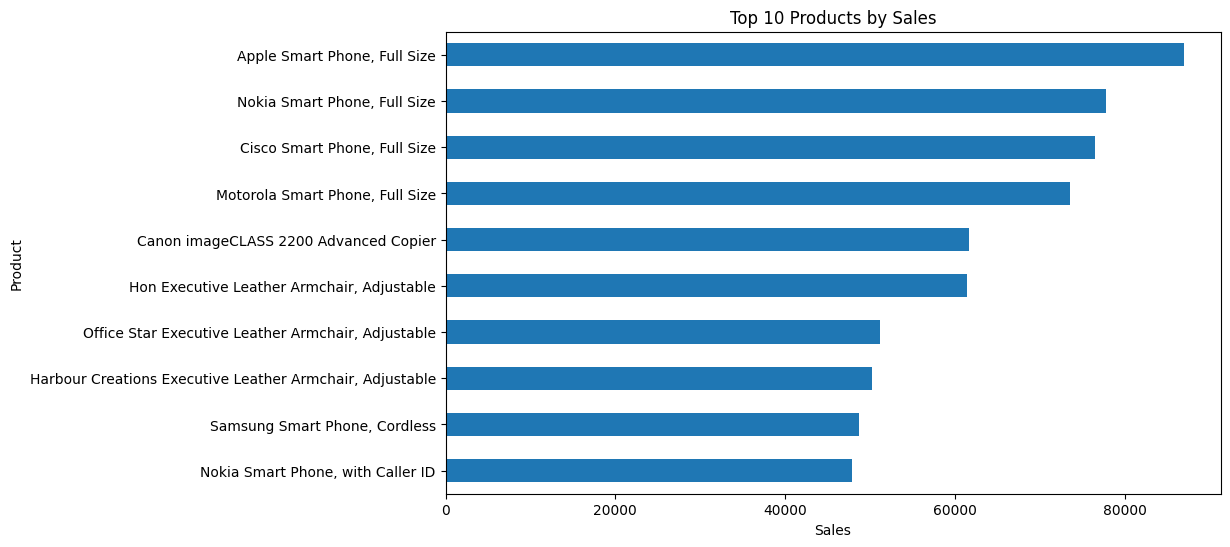

In [9]:
top_products = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product")
plt.show()

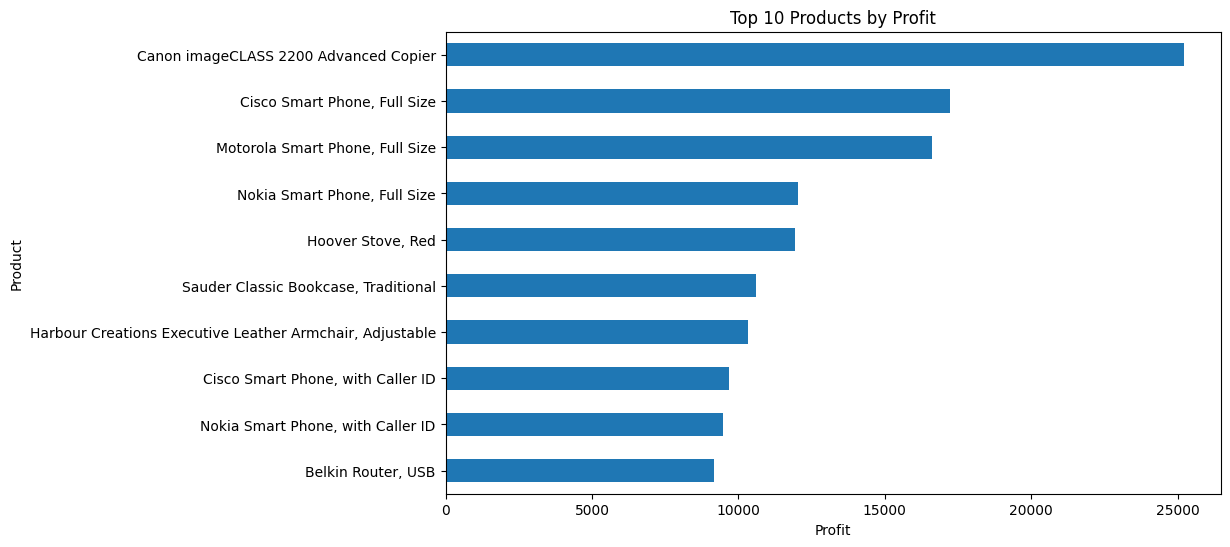

In [10]:
top_profit_products = (
    df.groupby("Product Name")["Profit"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
top_profit_products.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Profit")
plt.xlabel("Profit")
plt.ylabel("Product")
plt.show()

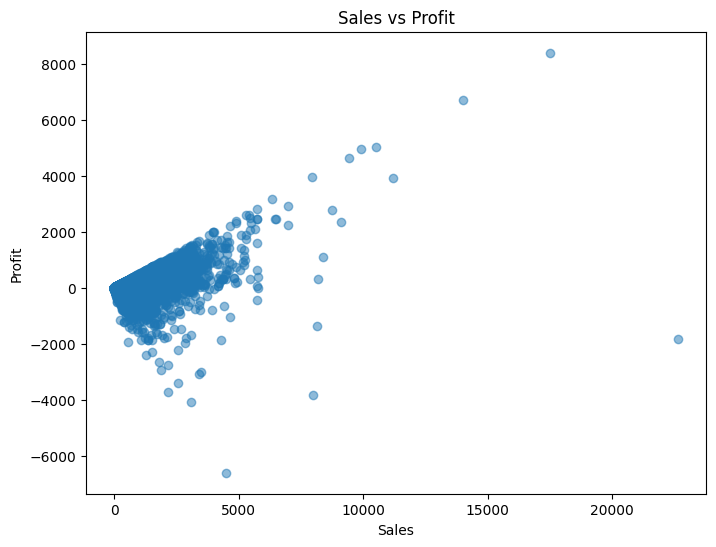

In [11]:
plt.figure(figsize=(8,6))

plt.scatter(df["Sales"], df["Profit"], alpha=0.5)

plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.show()

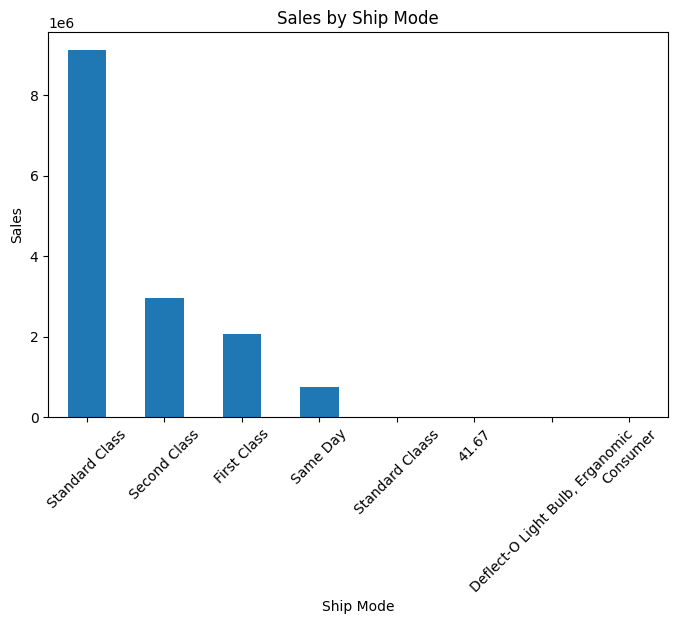

In [12]:
ship_sales = df.groupby("Ship Mode")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
ship_sales.plot(kind="bar")

plt.title("Sales by Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Sales")

plt.xticks(rotation=45)
plt.show()

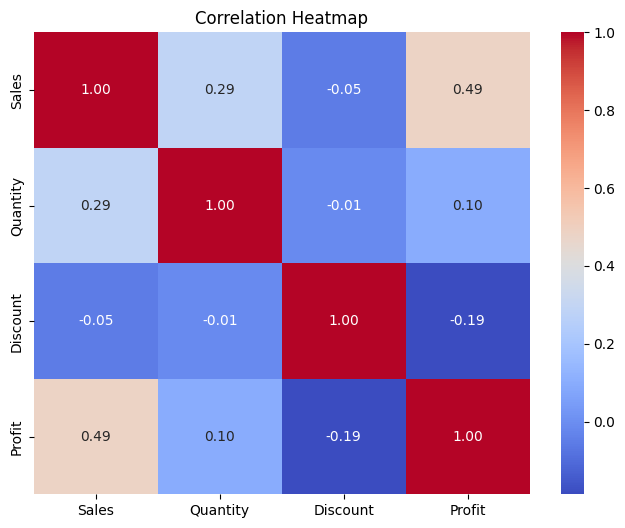

In [15]:
numeric_cols = [
    "Sales",
    "Quantity",
    "Discount",
    "Profit"
]

# Convert 'Discount' column to numeric, coercing errors to NaN
df["Discount"] = pd.to_numeric(df["Discount"], errors='coerce')

correlation = df[numeric_cols].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()